# Feature Engineering & Feature Importance Analysis

This notebook builds all price-based technical features, cross-ticker features, and calendar features from the raw OHLCV data. It then runs feature importance analysis to identify and select the most significant features for the modeling phase.

**Inputs:** `price.csv` (7 tickers, 241 trading days each)

**Outputs:** `features_price.csv` -- engineered feature matrix with importance rankings

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ta
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import IsolationForest
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100

DATA_DIR = '.'

## 1. Load and Prepare Data

In [2]:
price_df = pd.read_csv(f'{DATA_DIR}/price.csv', parse_dates=['date'])
price_df = price_df.sort_values(['ticker', 'date']).reset_index(drop=True)

tickers = sorted(price_df['ticker'].unique())
print(f'Tickers: {tickers}')
print(f'Shape: {price_df.shape}')
print(f'Date range: {price_df["date"].min().date()} to {price_df["date"].max().date()}')

Tickers: ['AAPL', 'AMZN', 'GOOGL', 'META', 'MSFT', 'NVDA', 'TSLA']
Shape: (1687, 7)
Date range: 2023-11-13 to 2024-10-28


## 2. Outlier Detection

Apply Isolation Forest per ticker to flag extreme anomalies, plus quantile clipping on returns (from SOTA Notebooks 3 & 4).

In [3]:
price_df['return_1d'] = price_df.groupby('ticker')['close'].pct_change()

iso_forest = IsolationForest(contamination=0.01, random_state=42)
outlier_counts = {}

for ticker in tickers:
    mask = price_df['ticker'] == ticker
    subset = price_df.loc[mask, ['open', 'high', 'low', 'close', 'volume']].dropna()
    labels = iso_forest.fit_predict(subset)
    n_outliers = (labels == -1).sum()
    outlier_counts[ticker] = n_outliers
    price_df.loc[subset.index[labels == -1], 'is_outlier'] = True

price_df['is_outlier'] = price_df['is_outlier'].fillna(False)

print('=== Outliers detected per ticker (Isolation Forest, contamination=0.01) ===')
for t, c in outlier_counts.items():
    print(f'  {t}: {c} outliers')
print(f'\nTotal outliers: {price_df["is_outlier"].sum()} / {len(price_df)}')
print('Note: Outliers are flagged but NOT removed -- the model can learn from them.')

=== Outliers detected per ticker (Isolation Forest, contamination=0.01) ===
  AAPL: 3 outliers
  AMZN: 3 outliers
  GOOGL: 3 outliers
  META: 3 outliers
  MSFT: 3 outliers
  NVDA: 3 outliers
  TSLA: 3 outliers

Total outliers: 21 / 1687
Note: Outliers are flagged but NOT removed -- the model can learn from them.


## 3. Technical Indicator Features

All features are computed **per ticker** to avoid cross-ticker contamination.

In [4]:
def compute_technical_features(df):
    """Compute all technical indicators for a single ticker's dataframe."""
    out = df.copy()
    close = out['close']
    high = out['high']
    low = out['low']
    volume = out['volume']

    # --- Returns ---
    out['return_1d'] = close.pct_change(1)
    out['return_5d'] = close.pct_change(5)
    out['return_10d'] = close.pct_change(10)
    out['return_20d'] = close.pct_change(20)
    out['log_return_1d'] = np.log(close / close.shift(1))

    # --- Moving Averages ---
    out['sma_5'] = ta.trend.sma_indicator(close, window=5)
    out['sma_10'] = ta.trend.sma_indicator(close, window=10)
    out['sma_20'] = ta.trend.sma_indicator(close, window=20)
    out['ema_12'] = ta.trend.ema_indicator(close, window=12)
    out['ema_26'] = ta.trend.ema_indicator(close, window=26)

    # Price relative to MAs (normalized distance)
    out['close_to_sma5'] = (close - out['sma_5']) / out['sma_5']
    out['close_to_sma20'] = (close - out['sma_20']) / out['sma_20']
    out['sma5_to_sma20'] = (out['sma_5'] - out['sma_20']) / out['sma_20']

    # --- Momentum ---
    out['rsi_14'] = ta.momentum.rsi(close, window=14)
    macd_obj = ta.trend.MACD(close, window_slow=26, window_fast=12, window_sign=9)
    out['macd'] = macd_obj.macd()
    out['macd_signal'] = macd_obj.macd_signal()
    out['macd_hist'] = macd_obj.macd_diff()
    stoch = ta.momentum.StochasticOscillator(high, low, close, window=14, smooth_window=3)
    out['stoch_k'] = stoch.stoch()
    out['stoch_d'] = stoch.stoch_signal()

    # --- Volatility ---
    bb = ta.volatility.BollingerBands(close, window=20, window_dev=2)
    out['bb_width'] = bb.bollinger_wband()
    out['bb_pctb'] = bb.bollinger_pband()
    out['atr_14'] = ta.volatility.average_true_range(high, low, close, window=14)
    out['volatility_5d'] = out['return_1d'].rolling(5).std()
    out['volatility_10d'] = out['return_1d'].rolling(10).std()
    out['volatility_20d'] = out['return_1d'].rolling(20).std()

    # --- Price Range (from SOTA Notebook 4) ---
    out['price_range'] = high - low
    out['price_range_pct'] = (high - low) / close

    # --- Volume features ---
    out['obv'] = ta.volume.on_balance_volume(close, volume)
    out['volume_sma_20'] = volume.rolling(20).mean()
    out['volume_ratio'] = volume / out['volume_sma_20']
    out['volume_change'] = volume.pct_change()

    # --- Lag features (for tree-based models) ---
    for lag in range(1, 6):
        out[f'close_lag_{lag}'] = close.shift(lag)
        out[f'return_lag_{lag}'] = out['return_1d'].shift(lag)

    # --- Calendar features ---
    out['day_of_week'] = out['date'].dt.dayofweek
    out['month'] = out['date'].dt.month
    out['is_month_start'] = out['date'].dt.is_month_start.astype(int)
    out['is_month_end'] = out['date'].dt.is_month_end.astype(int)

    return out

In [5]:
feature_dfs = []
for ticker in tickers:
    sub = price_df[price_df['ticker'] == ticker].copy()
    sub = compute_technical_features(sub)
    feature_dfs.append(sub)

features_df = pd.concat(feature_dfs, ignore_index=True)
print(f'Feature matrix shape (before NaN drop): {features_df.shape}')
print(f'Columns: {features_df.shape[1]}')
print(f'\nNaN counts per feature (top 15):')
display(features_df.isnull().sum().sort_values(ascending=False).head(15))

Feature matrix shape (before NaN drop): (1687, 53)
Columns: 53

NaN counts per feature (top 15):


macd_hist         231
macd_signal       231
macd              175
ema_26            175
volatility_20d    140
return_20d        140
sma5_to_sma20     133
sma_20            133
volume_ratio      133
volume_sma_20     133
bb_pctb           133
bb_width          133
close_to_sma20    133
stoch_d           105
rsi_14             91
dtype: int64

## 4. Cross-Ticker (Market) Features

In [6]:
market_return = (
    features_df
    .groupby('date')['return_1d']
    .mean()
    .rename('market_return')
)

features_df = features_df.merge(market_return, on='date', how='left')
features_df['relative_return'] = features_df['return_1d'] - features_df['market_return']

market_vol = (
    features_df
    .groupby('date')['return_1d']
    .std()
    .rename('market_volatility')
)
features_df = features_df.merge(market_vol, on='date', how='left')

print(f'Added cross-ticker features: market_return, relative_return, market_volatility')
print(f'Feature matrix shape: {features_df.shape}')

Added cross-ticker features: market_return, relative_return, market_volatility
Feature matrix shape: (1687, 56)


## 5. Target Variable

In [7]:
features_df['target_next_close'] = features_df.groupby('ticker')['close'].shift(-1)
features_df['target_next_return'] = features_df.groupby('ticker')['return_1d'].shift(-1)
features_df['target_direction'] = (features_df['target_next_return'] > 0).astype(int)

print('Target variables created:')
print('  - target_next_close:  next day closing price')
print('  - target_next_return: next day return (for alternative formulation)')
print('  - target_direction:   1 if next day up, 0 if down')
print(f'\nDirection distribution:')
display(features_df['target_direction'].value_counts(normalize=True))

Target variables created:
  - target_next_close:  next day closing price
  - target_next_return: next day return (for alternative formulation)
  - target_direction:   1 if next day up, 0 if down

Direction distribution:


target_direction
1    0.544161
0    0.455839
Name: proportion, dtype: float64

## 6. Handle NaN Rows

Technical indicators produce NaNs for the first N rows (warmup period). We drop these rows and the last row per ticker (no target available).

In [8]:
rows_before = len(features_df)

exclude_cols = ['date', 'ticker', 'is_outlier']
feature_cols_all = [
    c for c in features_df.columns
    if c not in exclude_cols
    and not c.startswith('target_')
    and c not in ['open', 'high', 'low', 'close', 'volume']
]

features_clean = features_df.dropna(subset=feature_cols_all + ['target_next_close']).copy()

rows_after = len(features_clean)
print(f'Rows before NaN drop: {rows_before}')
print(f'Rows after NaN drop:  {rows_after} (lost {rows_before - rows_after} warmup/tail rows)')
print(f'Rows per ticker: ~{rows_after // len(tickers)}')
print(f'\nFeature columns: {len(feature_cols_all)}')
print(feature_cols_all)

Rows before NaN drop: 1687
Rows after NaN drop:  1449 (lost 238 warmup/tail rows)
Rows per ticker: ~207

Feature columns: 48
['return_1d', 'return_5d', 'return_10d', 'return_20d', 'log_return_1d', 'sma_5', 'sma_10', 'sma_20', 'ema_12', 'ema_26', 'close_to_sma5', 'close_to_sma20', 'sma5_to_sma20', 'rsi_14', 'macd', 'macd_signal', 'macd_hist', 'stoch_k', 'stoch_d', 'bb_width', 'bb_pctb', 'atr_14', 'volatility_5d', 'volatility_10d', 'volatility_20d', 'price_range', 'price_range_pct', 'obv', 'volume_sma_20', 'volume_ratio', 'volume_change', 'close_lag_1', 'return_lag_1', 'close_lag_2', 'return_lag_2', 'close_lag_3', 'return_lag_3', 'close_lag_4', 'return_lag_4', 'close_lag_5', 'return_lag_5', 'day_of_week', 'month', 'is_month_start', 'is_month_end', 'market_return', 'relative_return', 'market_volatility']


## 7. Feature Correlation Analysis

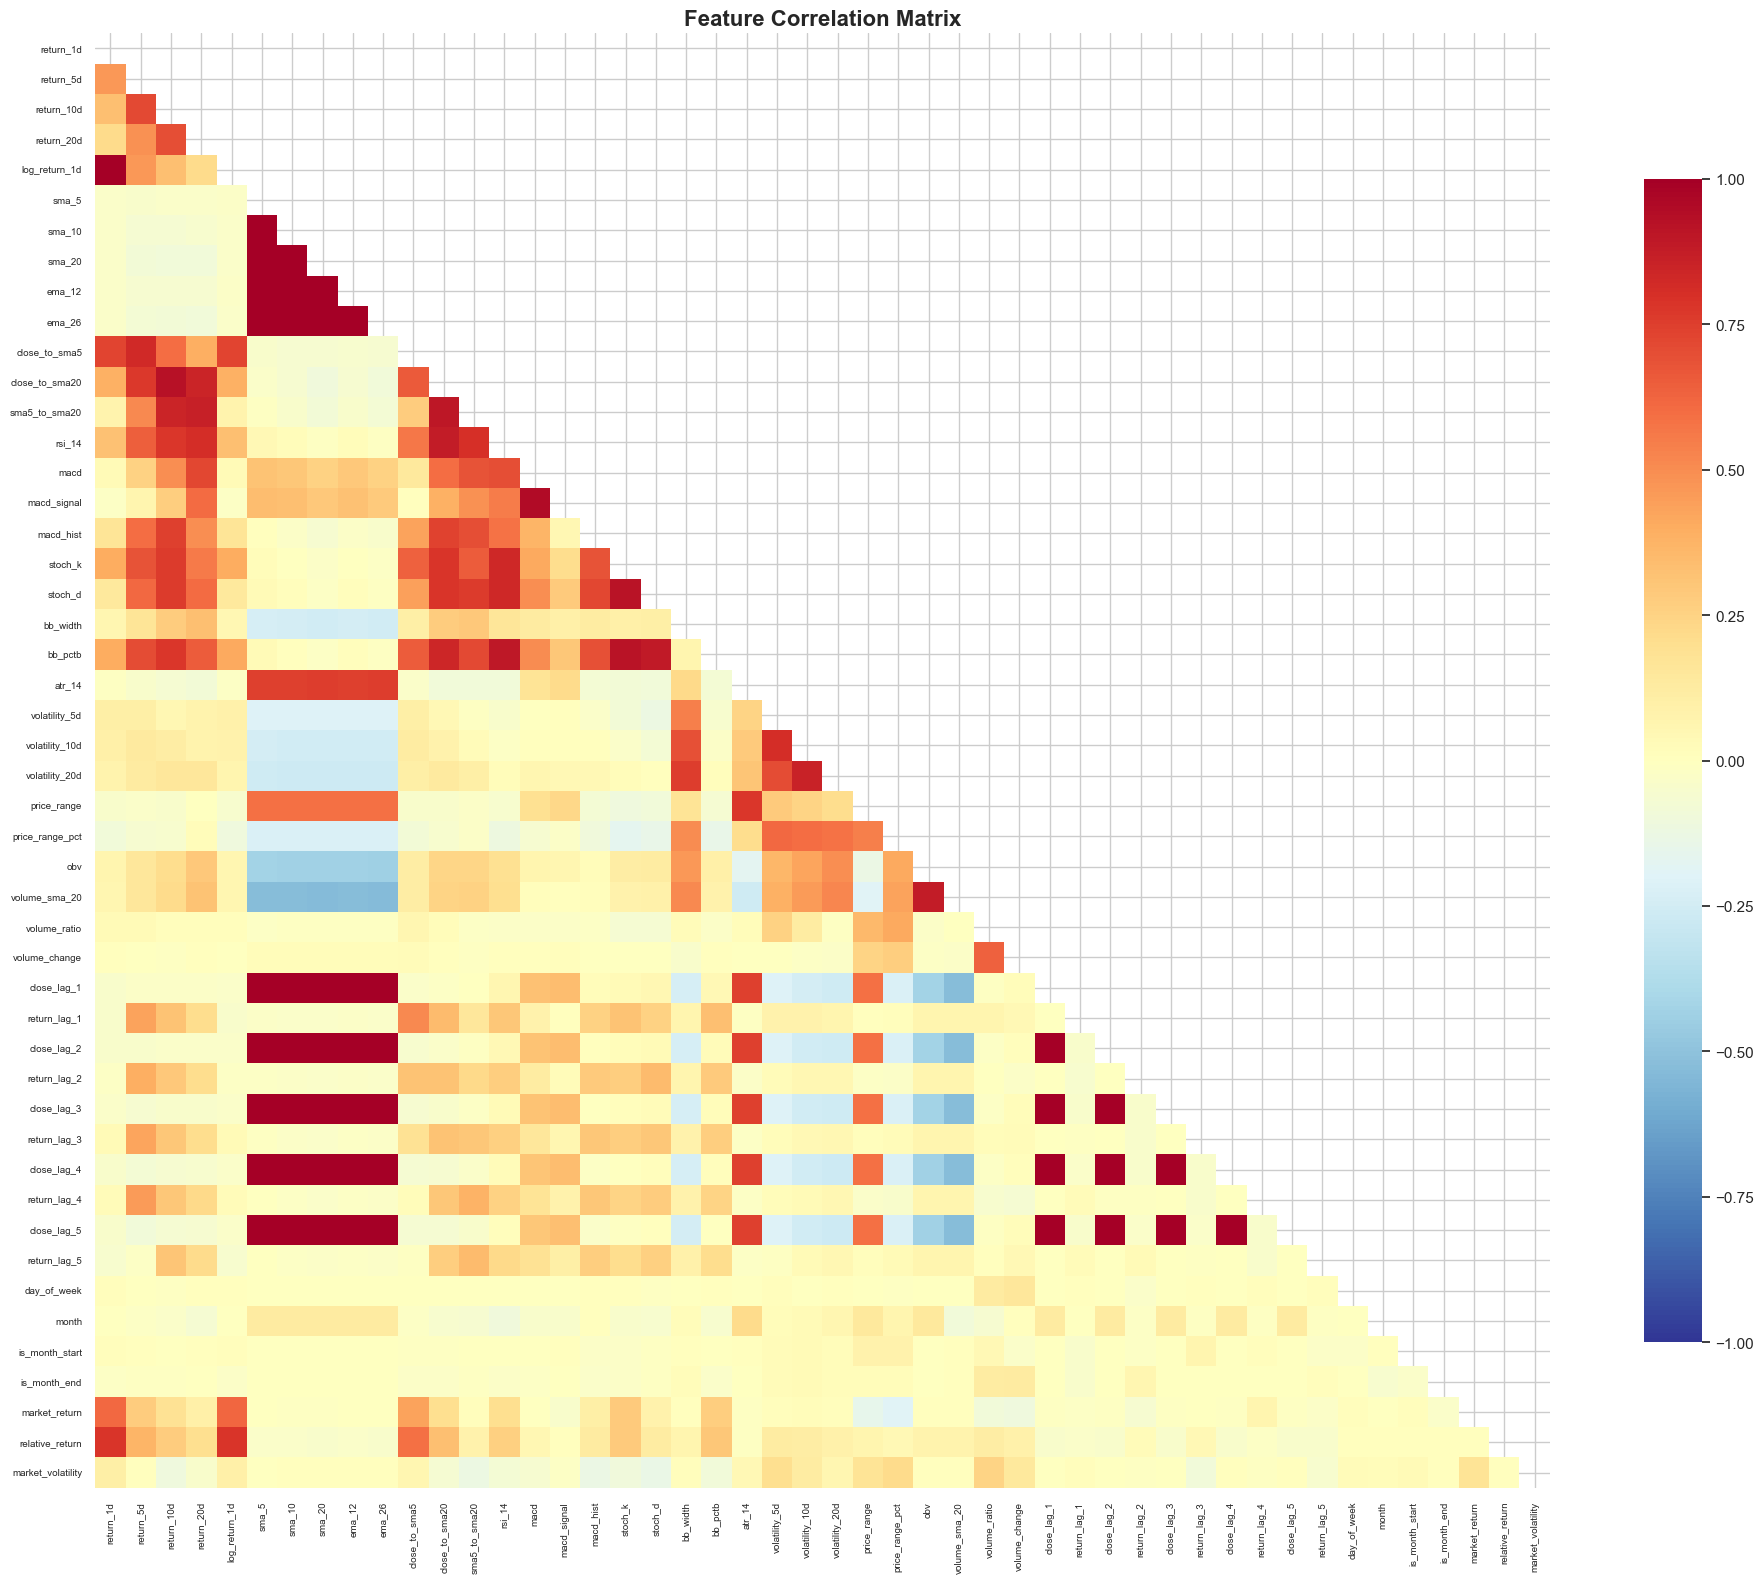

In [9]:
corr_matrix = features_clean[feature_cols_all].corr()

fig, ax = plt.subplots(figsize=(20, 16))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='RdYlBu_r', center=0,
            vmin=-1, vmax=1, square=True, ax=ax,
            xticklabels=True, yticklabels=True,
            cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix', fontsize=16, fontweight='bold')
ax.tick_params(axis='both', labelsize=7)
plt.tight_layout()
plt.show()

In [10]:
# Identify highly correlated feature pairs (|r| > 0.90)
high_corr_threshold = 0.90
upper = corr_matrix.where(mask == False)
high_corr_pairs = []

for col in upper.columns:
    for idx in upper.index:
        val = upper.loc[idx, col]
        if pd.notna(val) and abs(val) > high_corr_threshold and idx != col:
            high_corr_pairs.append((idx, col, round(val, 3)))

high_corr_pairs.sort(key=lambda x: abs(x[2]), reverse=True)

print(f'=== Highly correlated pairs (|r| > {high_corr_threshold}) ===')
print(f'Found {len(high_corr_pairs)} pairs:\n')
for f1, f2, r in high_corr_pairs[:20]:
    print(f'  {f1:<25} vs {f2:<25}  r = {r:+.3f}')

=== Highly correlated pairs (|r| > 0.9) ===
Found 51 pairs:

  close_lag_2               vs sma_5                      r = +1.000
  ema_12                    vs sma_10                     r = +1.000
  ema_26                    vs sma_20                     r = +1.000
  log_return_1d             vs return_1d                  r = +0.999
  sma_10                    vs sma_5                      r = +0.999
  ema_12                    vs sma_5                      r = +0.999
  close_lag_1               vs sma_5                      r = +0.999
  close_lag_3               vs sma_5                      r = +0.999
  close_lag_4               vs sma_5                      r = +0.999
  sma_20                    vs sma_10                     r = +0.999
  ema_26                    vs sma_10                     r = +0.999
  close_lag_2               vs sma_10                     r = +0.999
  close_lag_3               vs sma_10                     r = +0.999
  close_lag_4               vs sma_10     

## 8. Feature Importance -- XGBoost

Train a quick XGBoost model per ticker to rank features by importance. Uses time-based split to avoid leakage.

In [11]:
importance_results = {}

for ticker in tickers:
    sub = features_clean[features_clean['ticker'] == ticker].sort_values('date')
    X = sub[feature_cols_all].values
    y = sub['target_next_close'].values

    split_idx = int(len(X) * 0.8)
    X_train, X_test = X[:split_idx], X[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]

    model = xgb.XGBRegressor(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbosity=0
    )
    model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)

    importance = dict(zip(feature_cols_all, model.feature_importances_))
    importance_results[ticker] = importance

    print(f'{ticker}: RMSE={rmse:.2f}, MAE={mae:.2f}')

importance_df = pd.DataFrame(importance_results)
importance_df['mean_importance'] = importance_df.mean(axis=1)
importance_df = importance_df.sort_values('mean_importance', ascending=False)

print(f'\n=== Top 20 Features by Mean Importance Across Tickers ===')
display(importance_df['mean_importance'].head(20))

AAPL: RMSE=6.86, MAE=5.56
AMZN: RMSE=3.07, MAE=2.43
GOOGL: RMSE=8.82, MAE=8.11
META: RMSE=49.79, MAE=42.83
MSFT: RMSE=5.49, MAE=4.61
NVDA: RMSE=9.54, MAE=7.47
TSLA: RMSE=14.89, MAE=10.64

=== Top 20 Features by Mean Importance Across Tickers ===


sma_5             0.235321
close_lag_1       0.210709
sma_20            0.096131
ema_12            0.090305
sma_10            0.080864
close_lag_2       0.044389
ema_26            0.038242
obv               0.026840
close_lag_3       0.019583
atr_14            0.013315
bb_pctb           0.012710
close_to_sma20    0.012376
month             0.009312
rsi_14            0.008977
sma5_to_sma20     0.008889
macd              0.007485
close_lag_4       0.006574
macd_hist         0.005145
macd_signal       0.005009
return_20d        0.004547
Name: mean_importance, dtype: float32

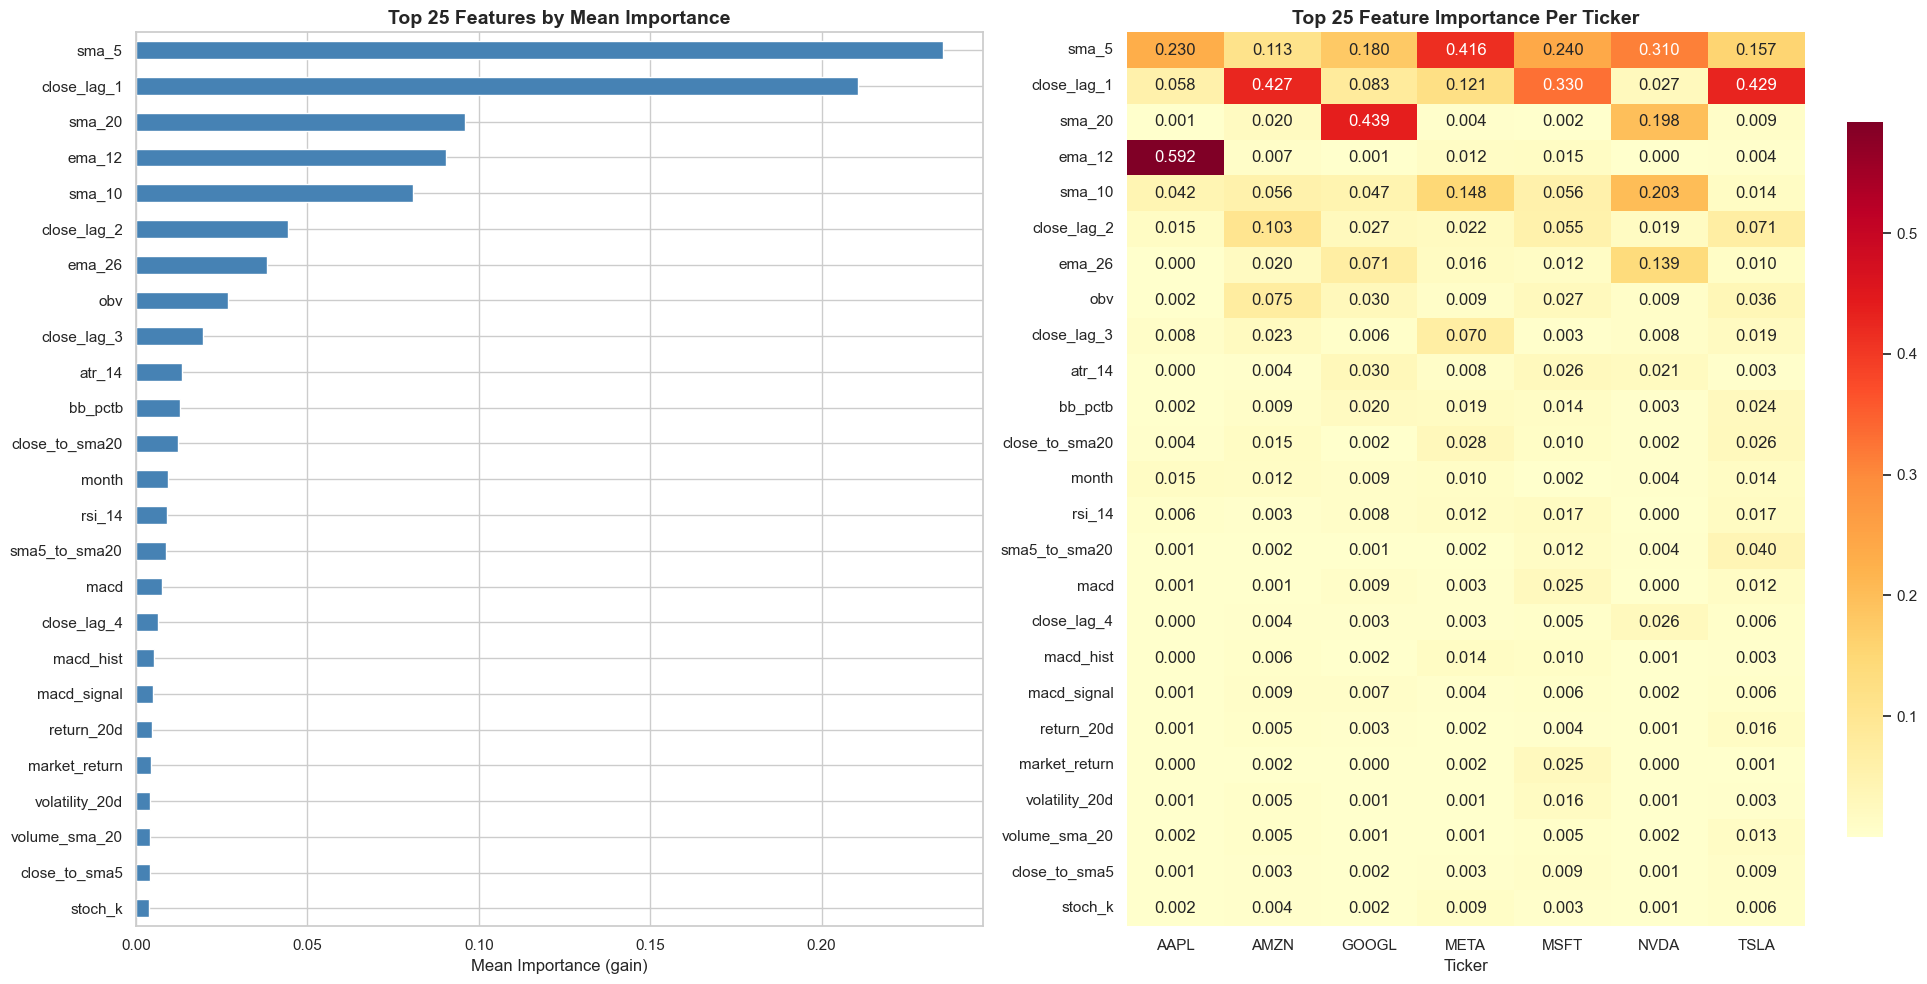

In [12]:
# Feature importance visualization
top_n = 25
top_features = importance_df.head(top_n)

fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# Mean importance bar chart
top_features['mean_importance'].plot(
    kind='barh', ax=axes[0], color='steelblue', edgecolor='white'
)
axes[0].set_xlabel('Mean Importance (gain)', fontsize=12)
axes[0].set_title(f'Top {top_n} Features by Mean Importance', fontsize=14, fontweight='bold')
axes[0].invert_yaxis()

# Per-ticker heatmap of importance
sns.heatmap(
    top_features[tickers],
    cmap='YlOrRd', annot=True, fmt='.3f',
    ax=axes[1], cbar_kws={'shrink': 0.8}
)
axes[1].set_title(f'Top {top_n} Feature Importance Per Ticker', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Ticker')

plt.tight_layout()
plt.show()

## 9. Feature Importance -- Correlation with Target

=== Top 20 Features by Mean |correlation| with Next-Day Return ===


close_lag_1          0.141806
sma_5                0.139273
sma_10               0.138121
ema_12               0.137243
close_lag_4          0.136333
close_lag_3          0.131634
close_lag_5          0.127980
ema_26               0.127435
close_lag_2          0.126781
sma_20               0.125991
obv                  0.101861
market_volatility    0.078047
return_lag_1         0.072801
volume_change        0.072647
return_lag_2         0.069649
volume_sma_20        0.067327
month                0.065306
is_month_end         0.061431
is_month_start       0.061411
volume_ratio         0.060770
Name: mean_abs_corr, dtype: float64

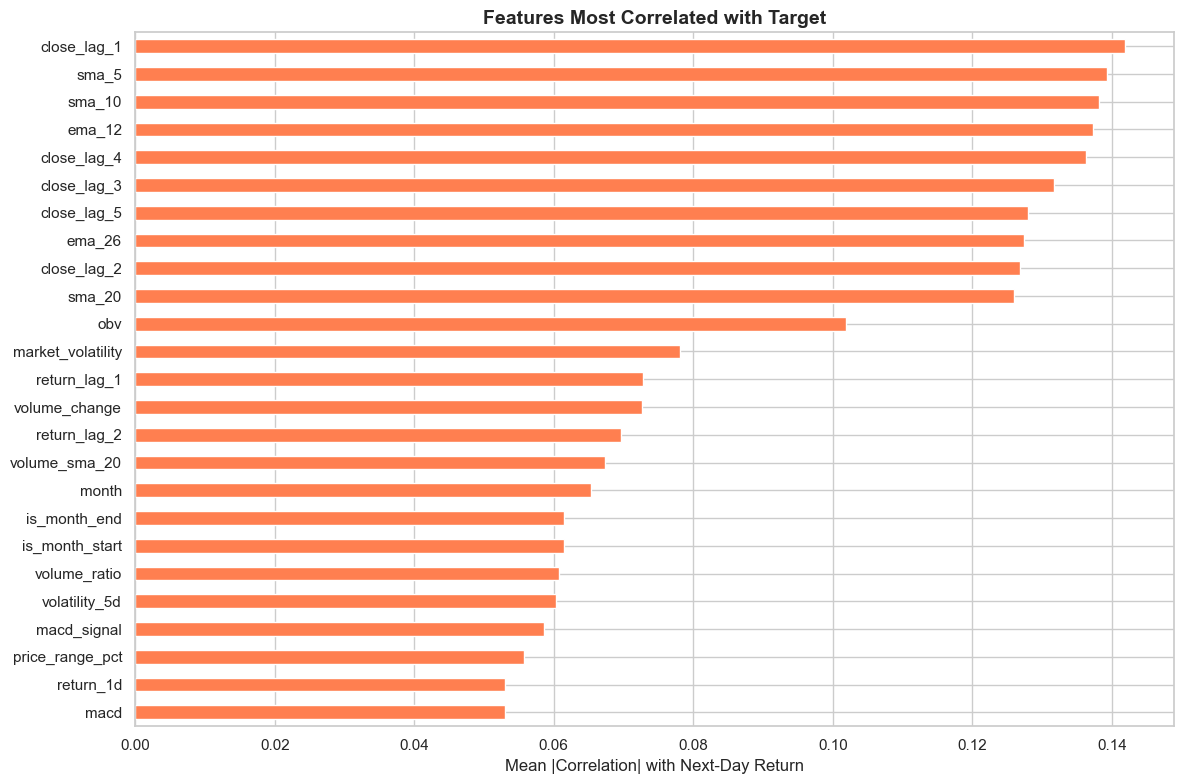

In [13]:
target_corr_results = {}

for ticker in tickers:
    sub = features_clean[features_clean['ticker'] == ticker]
    corrs = sub[feature_cols_all].corrwith(sub['target_next_return']).abs()
    target_corr_results[ticker] = corrs

target_corr_df = pd.DataFrame(target_corr_results)
target_corr_df['mean_abs_corr'] = target_corr_df.mean(axis=1)
target_corr_df = target_corr_df.sort_values('mean_abs_corr', ascending=False)

print('=== Top 20 Features by Mean |correlation| with Next-Day Return ===')
display(target_corr_df['mean_abs_corr'].head(20))

fig, ax = plt.subplots(figsize=(12, 8))
target_corr_df['mean_abs_corr'].head(25).plot(
    kind='barh', ax=ax, color='coral', edgecolor='white'
)
ax.set_xlabel('Mean |Correlation| with Next-Day Return', fontsize=12)
ax.set_title('Features Most Correlated with Target', fontsize=14, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 10. Feature Selection

Combine XGBoost importance + target correlation + redundancy removal to select the final feature set.

In [14]:
# Combine both rankings into a unified score
importance_rank = importance_df['mean_importance'].rank(ascending=False)
corr_rank = target_corr_df['mean_abs_corr'].rank(ascending=False)

combined = pd.DataFrame({
    'xgb_importance': importance_df['mean_importance'],
    'xgb_rank': importance_rank,
    'target_corr': target_corr_df['mean_abs_corr'],
    'corr_rank': corr_rank,
}).dropna()

combined['combined_rank'] = (combined['xgb_rank'] + combined['corr_rank']) / 2
combined = combined.sort_values('combined_rank')

print('=== Combined Feature Ranking (lower = better) ===')
display(combined.head(30))

=== Combined Feature Ranking (lower = better) ===


,xgb_importance,xgb_rank,target_corr,corr_rank,combined_rank
sma_5,0.235321,1.0,0.139273,2.0,1.5
close_lag_1,0.210709,2.0,0.141806,1.0,1.5
sma_10,0.080864,5.0,0.138121,3.0,4.0
ema_12,0.090305,4.0,0.137243,4.0,4.0
sma_20,0.096131,3.0,0.125991,10.0,6.5
close_lag_2,0.044389,6.0,0.126781,9.0,7.5
close_lag_3,0.019583,9.0,0.131634,6.0,7.5
ema_26,0.038242,7.0,0.127435,8.0,7.5
obv,0.026840,8.0,0.101861,11.0,9.5
close_lag_4,0.006574,17.0,0.136333,5.0,11.0


In [15]:
def remove_redundant_features(feature_list, corr_matrix, threshold=0.95):
    """Remove features with correlation > threshold, keeping the higher-ranked one."""
    selected = list(feature_list)
    removed = []

    for i in range(len(selected)):
        if selected[i] is None:
            continue
        for j in range(i + 1, len(selected)):
            if selected[j] is None:
                continue
            if abs(corr_matrix.loc[selected[i], selected[j]]) > threshold:
                removed.append((selected[j], selected[i], corr_matrix.loc[selected[i], selected[j]]))
                selected[j] = None

    selected = [f for f in selected if f is not None]
    return selected, removed


ranked_features = combined.index.tolist()
corr_for_selection = features_clean[feature_cols_all].corr()

selected_features, removed_features = remove_redundant_features(
    ranked_features, corr_for_selection, threshold=0.95
)

print(f'=== Feature Selection Results ===')
print(f'Total features before:  {len(ranked_features)}')
print(f'Removed (redundant):    {len(removed_features)}')
print(f'Selected features:      {len(selected_features)}')

if removed_features:
    print(f'\nRemoved features (corr > 0.95 with a higher-ranked feature):')
    for dropped, kept, r in removed_features:
        print(f'  Dropped: {dropped:<25} (kept: {kept:<25}, r={r:.3f})')

print(f'\n=== Final Selected Price Features ({len(selected_features)}) ===')
for i, f in enumerate(selected_features, 1):
    xgb_imp = combined.loc[f, 'xgb_importance'] if f in combined.index else 0
    tgt_corr = combined.loc[f, 'target_corr'] if f in combined.index else 0
    print(f'  {i:2d}. {f:<28} XGB={xgb_imp:.4f}  |r_target|={tgt_corr:.4f}')

=== Feature Selection Results ===
Total features before:  48
Removed (redundant):    10
Selected features:      38

Removed features (corr > 0.95 with a higher-ranked feature):
  Dropped: close_lag_1               (kept: sma_5                    , r=0.999)
  Dropped: sma_10                    (kept: sma_5                    , r=0.999)
  Dropped: ema_12                    (kept: sma_5                    , r=0.999)
  Dropped: sma_20                    (kept: sma_5                    , r=0.997)
  Dropped: close_lag_2               (kept: sma_5                    , r=1.000)
  Dropped: close_lag_3               (kept: sma_5                    , r=0.999)
  Dropped: ema_26                    (kept: sma_5                    , r=0.997)
  Dropped: close_lag_4               (kept: sma_5                    , r=0.999)
  Dropped: close_lag_5               (kept: sma_5                    , r=0.998)
  Dropped: return_1d                 (kept: log_return_1d            , r=0.999)

=== Final Selected Pri

## 11. Quick Validation: Selected Features vs All Features

In [16]:
results_comparison = []

for ticker in tickers:
    sub = features_clean[features_clean['ticker'] == ticker].sort_values('date')
    y = sub['target_next_close'].values
    split_idx = int(len(y) * 0.8)

    for label, cols in [('All features', feature_cols_all), ('Selected features', selected_features)]:
        X = sub[cols].values
        X_train, X_test = X[:split_idx], X[split_idx:]
        y_train, y_test = y[:split_idx], y[split_idx:]

        model = xgb.XGBRegressor(
            n_estimators=200, max_depth=4, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            random_state=42, verbosity=0
        )
        model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
        y_pred = model.predict(X_test)

        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mae = mean_absolute_error(y_test, y_pred)
        naive_rmse = np.sqrt(mean_squared_error(y_test[1:], y_test[:-1]))

        results_comparison.append({
            'ticker': ticker,
            'feature_set': label,
            'n_features': len(cols),
            'RMSE': round(rmse, 2),
            'MAE': round(mae, 2),
            'Naive_RMSE': round(naive_rmse, 2),
            'vs_naive': f'{rmse/naive_rmse:.2%}'
        })

results_df = pd.DataFrame(results_comparison)

print('=== All Features vs Selected Features (80/20 time split) ===')
display(results_df.pivot_table(
    index='ticker',
    columns='feature_set',
    values=['RMSE', 'n_features'],
    aggfunc='first'
))

print('\nIf Selected RMSE is similar to or better than All, feature selection is effective.')
print('If worse, we may need to keep more features or adjust the threshold.')

=== All Features vs Selected Features (80/20 time split) ===


RMSE                     n_features                  
feature_set All features Selected features All features Selected features
ticker                                                                   
AAPL                6.86              9.15           48                38
AMZN                3.07              3.76           48                38
GOOGL               8.82              6.55           48                38
META               49.79             51.63           48                38
MSFT                5.49              5.46           48                38
NVDA                9.54              9.19           48                38
TSLA               14.89             15.34           48                38


If Selected RMSE is similar to or better than All, feature selection is effective.
If worse, we may need to keep more features or adjust the threshold.


## 12. Save Engineered Features

In [17]:
output_cols = ['date', 'ticker'] + selected_features + [
    'open', 'high', 'low', 'close', 'volume',
    'target_next_close', 'target_next_return', 'target_direction', 'is_outlier'
]

output_df = features_clean[output_cols].copy()
output_df.to_csv(f'{DATA_DIR}/features_price.csv', index=False)

print(f'Saved: features_price.csv')
print(f'Shape: {output_df.shape}')
print(f'Columns: {list(output_df.columns)}')
print(f'\nDate range: {output_df["date"].min()} to {output_df["date"].max()}')
print(f'Rows per ticker:')
display(output_df.groupby('ticker').size())

Saved: features_price.csv
Shape: (1449, 49)
Columns: ['date', 'ticker', 'sma_5', 'obv', 'month', 'volume_sma_20', 'macd_signal', 'macd', 'atr_14', 'close_to_sma20', 'volume_ratio', 'market_return', 'market_volatility', 'rsi_14', 'log_return_1d', 'return_20d', 'volatility_5d', 'sma5_to_sma20', 'bb_pctb', 'return_lag_2', 'volume_change', 'price_range_pct', 'return_lag_1', 'close_to_sma5', 'relative_return', 'macd_hist', 'volatility_10d', 'volatility_20d', 'is_month_start', 'is_month_end', 'return_5d', 'return_10d', 'return_lag_4', 'price_range', 'stoch_k', 'bb_width', 'return_lag_3', 'return_lag_5', 'stoch_d', 'day_of_week', 'open', 'high', 'low', 'close', 'volume', 'target_next_close', 'target_next_return', 'target_direction', 'is_outlier']

Date range: 2024-01-02 00:00:00 to 2024-10-25 00:00:00
Rows per ticker:


ticker
AAPL     207
AMZN     207
GOOGL    207
META     207
MSFT     207
NVDA     207
TSLA     207
dtype: int64

## Summary

**Feature engineering pipeline completed:**

1. **Outlier detection** -- Isolation Forest flagging (not removal)
2. **Technical indicators** -- returns, MAs, momentum (RSI, MACD, Stochastic), volatility (BB, ATR, rolling std), price range, volume features, lags, calendar
3. **Cross-ticker features** -- market mean return, relative return, market volatility
4. **Feature importance** -- XGBoost gain + target correlation, dual ranking
5. **Redundancy removal** -- correlation threshold at 0.95 to drop near-duplicate features
6. **Validation** -- selected vs all features comparison against naive baseline

**Next step:** NLP feature engineering (FinBERT sentiment + sentence embeddings) in a separate notebook, then merge with these price features for modeling.